In [56]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import os
os.makedirs("../reports/figures", exist_ok=True)

In [57]:
df = pd.read_csv("../data/processed/combined_clean.csv")

df_nlp = df[['respondent_id', 'regret_description', 'regret_intensity']].dropna()

print("Shape:", df_nlp.shape)

Shape: (21, 3)


In [58]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    return tokens

df_nlp['tokens'] = df_nlp['regret_description'].apply(clean_text)

df_nlp['cleaned_text'] = df_nlp['tokens'].apply(lambda x: " ".join(x))

In [59]:
df_nlp['polarity'] = df_nlp['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_nlp['subjectivity'] = df_nlp['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

mean_polarity = df_nlp['polarity'].mean()
mean_subjectivity = df_nlp['subjectivity'].mean()

print("Mean Polarity:", mean_polarity)
print("Mean Subjectivity:", mean_subjectivity)

Mean Polarity: 0.0246655328798186
Mean Subjectivity: 0.33301870748299317


In [60]:
corr_matrix = df_nlp[['polarity', 'regret_intensity']].corr()
print(corr_matrix)

                  polarity  regret_intensity
polarity          1.000000          0.020296
regret_intensity  0.020296          1.000000


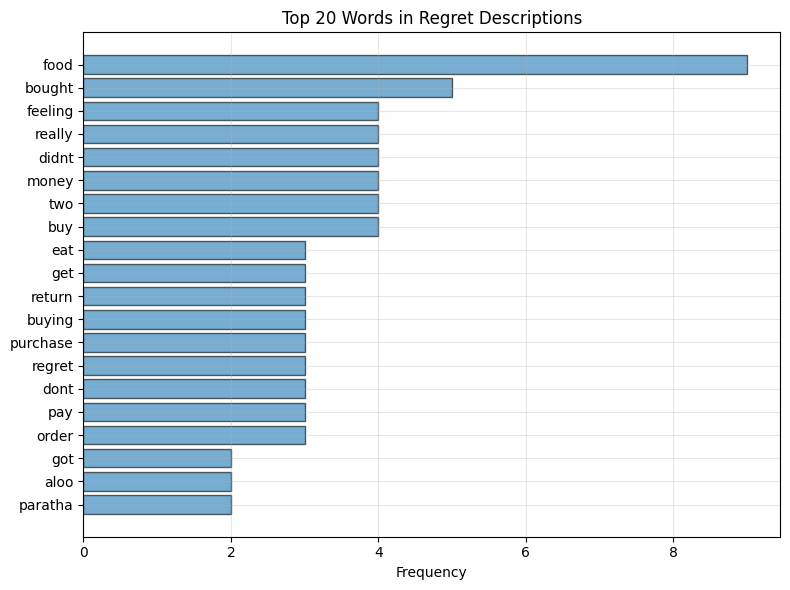

In [61]:
all_words = [word for tokens in df_nlp['tokens'] for word in tokens]

word_freq = Counter(all_words)

top_words = word_freq.most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(8,6))
plt.barh(words[::-1], counts[::-1],alpha=0.6,edgecolor="Black")
plt.title("Top 20 Words in Regret Descriptions")
plt.xlabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/plot_13_word_frequency.png", dpi=150)
plt.show()

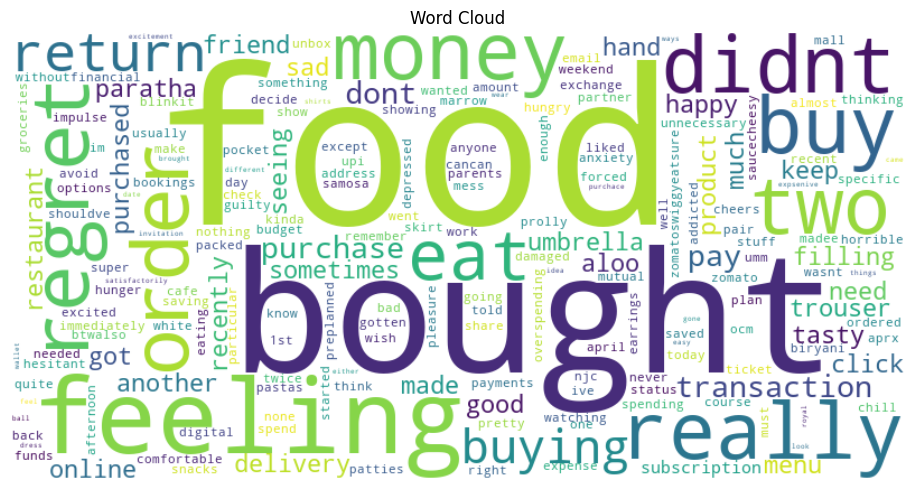

In [62]:
text_blob = " ".join(all_words)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_blob)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")

plt.tight_layout()
plt.savefig("../reports/figures/plot_14_wordcloud.png", dpi=150)
plt.show()

In [63]:
tag_map = {
    1000: "Need",
    2006: "Cravings",
    2010: "Emotional",
    2017: "Need",
    2026: "Poor Planning",
    2029: "Cravings",
    3002: "Offers",
    3004: "Poor Planning",
    3010: "Cravings",
    3023: "Laziness",
    3024: "Social Influence",
    3026: "Need",
    3030: "Planned",
    3032: "Social Influence",
    3037: "Emotional",
    3044: "Emotional",
    3046: "Poor Planning",
    3048: "Poor Planning",
    4000: "Cravings",
    4002: "Emotional",
    4005: "Need"
}

df_nlp['trigger_tag'] = df_nlp['respondent_id'].map(tag_map)

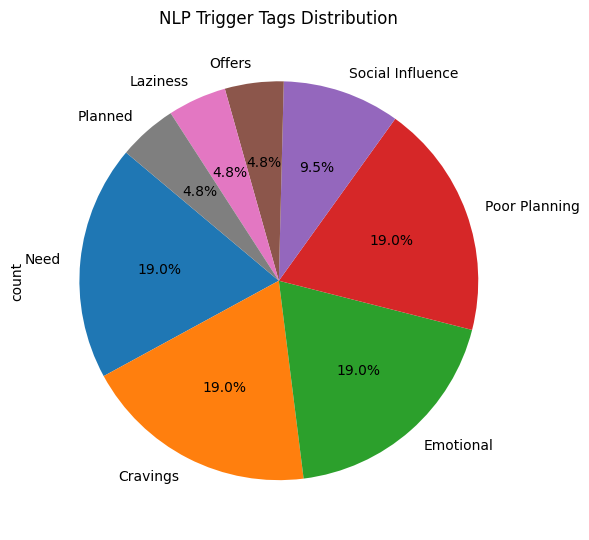

In [64]:
plt.figure(figsize=(6,6))

df_nlp['trigger_tag'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140
)

plt.title("NLP Trigger Tags Distribution")

plt.tight_layout()
plt.savefig("../reports/figures/plot_15_nlp_trigger_tags.png", dpi=150)
plt.show()